**Question (a)**  
Generate a simulated data set as follows:

```
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
```

In this data set, what is n and what is p? Write out the model used to generate the data in equation form.


In [7]:
# Simulation set-up for all parts of the exercise.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

rng = np.random.default_rng(1)
X = rng.normal(size=100).reshape(-1, 1)
noise = rng.normal(size=100)
y = X[:, 0] - 2 * X[:, 0]**2 + noise

data = pd.DataFrame({"X": X[:, 0], "Y": y})

n = data.shape[0]
p = 1  # There is a single predictor X.
print(f"n = {n}, p = {p}")
print("Model: Y = X - 2X^2 + ε, with ε ~ N(0, 1)")
display(data.head())


n = 100, p = 1
Model: Y = X - 2X^2 + ε, with ε ~ N(0, 1)


,X,Y
0,0.345584,-0.544554
1,0.821618,0.333950
2,0.330437,-0.013532
3,-1.303157,-4.030442
4,0.905356,0.484861


**Question (b)**  
Create a scatterplot of X against Y. Comment on what you find.


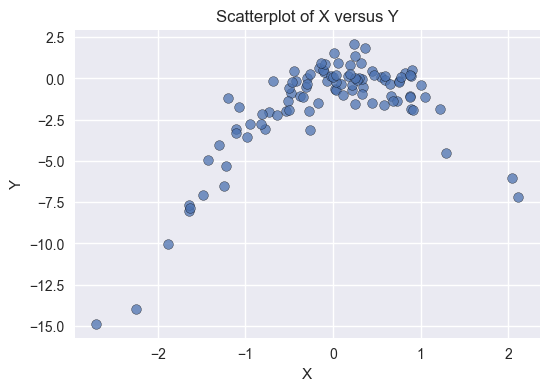

The data follow a downward-opening curved relationship, consistent with the negative quadratic term in the data-generating process.


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(data["X"], data["Y"], alpha=0.75, edgecolor="black")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Scatterplot of X versus Y")
plt.show()

print(
    "The data follow a downward-opening curved relationship, consistent with the "
    "negative quadratic term in the data-generating process."
)


**Question (c)**  
Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

i. Y = β₀ + β₁X + ε  
ii. Y = β₀ + β₁X + β₂X² + ε  
iii. Y = β₀ + β₁X + β₂X² + β₃X³ + ε  
iv. Y = β₀ + β₁X + β₂X² + β₃X³ + β₄X⁴ + ε

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y.


In [9]:
def compute_loocv(x_values: np.ndarray, y_values: np.ndarray, max_degree: int = 4) -> pd.DataFrame:
    base_X = x_values.reshape(-1, 1)
    loo = LeaveOneOut()
    rows = []
    for degree in range(1, max_degree + 1):
        poly = PolynomialFeatures(degree=degree, include_bias=False)
        X_poly = poly.fit_transform(base_X)
        preds = np.zeros_like(y_values)
        for train_idx, test_idx in loo.split(X_poly):
            model = LinearRegression()
            model.fit(X_poly[train_idx], y_values[train_idx])
            preds[test_idx] = model.predict(X_poly[test_idx])
        mse = np.mean((y_values - preds) ** 2)
        rows.append({"Model": f"Degree {degree}", "LOOCV MSE": mse})
    return pd.DataFrame(rows).set_index("Model")

loocv_results = compute_loocv(data["X"].values, data["Y"].values)
display(loocv_results.round(4))
print("The seed was fixed at 1 via rng.default_rng(1) in part (a).")


,LOOCV MSE
Model,
Degree 1,6.6330
Degree 2,1.1229
Degree 3,1.3018
Degree 4,1.3324


The seed was fixed at 1 via rng.default_rng(1) in part (a).


**Question (d)**  
Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?


In [10]:
alt_seed = 3
alt_rng = np.random.default_rng(alt_seed)
alt_X = alt_rng.normal(size=100)
alt_noise = alt_rng.normal(size=100)
alt_y = alt_X - 2 * alt_X**2 + alt_noise

alt_loocv_results = compute_loocv(alt_X, alt_y)
display(alt_loocv_results.round(4))

comparison = pd.concat(
    [
        loocv_results.rename(columns={"LOOCV MSE": "Seed 1"}),
        alt_loocv_results.rename(columns={"LOOCV MSE": "Seed 3"}),
    ],
    axis=1,
)
display(comparison.round(4))

deg1_seed1 = loocv_results.loc["Degree 1", "LOOCV MSE"]
deg1_seed3 = alt_loocv_results.loc["Degree 1", "LOOCV MSE"]
print(
    "Changing the RNG seed to {alt_seed} generates a different sample and noise draw, "
    "so the LOOCV MSE values shift (e.g., degree-1 increases from "
    f"{deg1_seed1:.4f} to {deg1_seed3:.4f}). The quadratic model still wins because "
    "the underlying data-generating mechanism remains quadratic."
)


,LOOCV MSE
Model,
Degree 1,14.5588
Degree 2,1.0449
Degree 3,0.9342
Degree 4,0.9466


,Seed 1,Seed 3
Model,,
Degree 1,6.6330,14.5588
Degree 2,1.1229,1.0449
Degree 3,1.3018,0.9342
Degree 4,1.3324,0.9466


Changing the RNG seed to {alt_seed} generates a different sample and noise draw, so the LOOCV MSE values shift (e.g., degree-1 increases from 6.6330 to 14.5588). The quadratic model still wins because the underlying data-generating mechanism remains quadratic.


**Question (e)**  
Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.


In [11]:
best_model = loocv_results["LOOCV MSE"].idxmin()
best_error = loocv_results.loc[best_model, "LOOCV MSE"]
print(f"The smallest LOOCV error comes from {best_model} with MSE {best_error:.4f}.")
print(
    "This matches expectations because the data were generated from a quadratic "
    "relationship, so including X^2 captures the signal while avoiding the extra "
    "variance introduced by higher-degree polynomials."
)


The smallest LOOCV error comes from Degree 2 with MSE 1.1229.
This matches expectations because the data were generated from a quadratic relationship, so including X^2 captures the signal while avoiding the extra variance introduced by higher-degree polynomials.


**Question (f)**  
Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?


In [12]:
def summarize_coefficients(x_values: np.ndarray, y_values: np.ndarray, degree: int) -> pd.DataFrame:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x_values.reshape(-1, 1))
    design = sm.add_constant(X_poly)
    labels = ["Intercept"] + [f"X^{power}" for power in range(1, degree + 1)]
    model = sm.OLS(y_values, design).fit()
    summary = pd.DataFrame({"Coefficient": model.params, "p-value": model.pvalues}, index=labels)
    return summary

coef_tables = {
    f"Degree {degree}": summarize_coefficients(data["X"].values, data["Y"].values, degree)
    for degree in range(1, 5)
}

for label, table in coef_tables.items():
    print(label)
    display(table)
    print()

print(
    "The quadratic terms (X and X^2) are highly significant, whereas the extra "
    "cubic and quartic terms have large p-values that signal little additional "
    "explanatory power aside from occasional noisy effects. This mirrors the "
    "cross-validation findings that the quadratic specification generalizes best."
)


Degree 1


,Coefficient,p-value
Intercept,-1.464963,4.409621e-08
X^1,1.949369,1.036506e-09



Degree 2


,Coefficient,p-value
Intercept,-0.072755,5.428243e-01
X^1,0.966273,1.494913e-11
X^2,-2.004709,1.340068e-39



Degree 3


,Coefficient,p-value
Intercept,-0.057197,6.345015e-01
X^1,1.114584,4.448516e-08
X^2,-2.047094,3.968906e-37
X^3,-0.064300,2.872018e-01



Degree 4


,Coefficient,p-value
Intercept,0.100848,4.596053e-01
X^1,0.904998,2.591296e-05
X^2,-2.505923,2.396026e-19
X^3,0.033768,6.424910e-01
X^4,0.104217,2.310661e-02



The quadratic terms (X and X^2) are highly significant, whereas the extra cubic and quartic terms have large p-values that signal little additional explanatory power aside from occasional noisy effects. This mirrors the cross-validation findings that the quadratic specification generalizes best.
